In [1]:
import sys
import argparse

sys.argv = ['script_name', '--forward_amount', '0.5']

parser = argparse.ArgumentParser()
parser.add_argument('--forward_amount', type=float, help='前进的距离')

args = parser.parse_args()

from config import config
from env.v0d0 import Env
import torch
import pickle
import numpy as np
import habitat_sim
from habitat.utils.visualizations import maps
import random
from draw import Draw
env = Env(config)
env.reset()

/home/getuanhui/anaconda3/envs/ss/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-03-02 16:39:25.370497: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-02 16:39:25.388456: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-02 16:39:25.388479: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-02 16:39

[16:39:26:711413]:[Metadata] AttributesManagerBase.h(380)::createFromJsonOrDefaultInternal : <Dataset>: Proposing JSON name : default.scene_dataset_config.json from original name : default| This file does not exist.
[16:39:26:711458]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (capsule3DSolid:capsule3DSolid_hemiRings_4_cylRings_1_segments_12_halfLen_0.75_useTexCoords_false_useTangents_false) created and registered.
[16:39:26:711471]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (capsule3DWireframe:capsule3DWireframe_hemiRings_8_cylRings_1_segments_16_halfLen_1) created and registered.
[16:39:26:711479]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (coneSolid:coneSolid_segments_12_halfLen_1.25_rings_1_useTexCoords_false_useTangents_false_capEnd_true) created and registered.
[16:39:26:711487]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (coneWireframe:coneWireframe_s

[16:39:26:712172]:[Metadata] SceneDatasetAttributesManager.cpp(308)::readDatasetJSONCell : "stages.default_attributes" set in Attributes Manager from JSON.
[16:39:26:712197]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for ../data/scene_datasets/mp3d/*/*.glb : ../data/scene_datasets/mp3d/17DRP5sb8fy/17DRP5sb8fy.glb
[16:39:26:712243]:[Metadata] SceneInstanceAttributesManager.cpp(65)::setValsFromJSONDoc : No Stage specified for scene default_attributes , or specification error.
[16:39:26:712246]:[Metadata] SceneInstanceAttributesManager.cpp(105)::setValsFromJSONDoc : No Articulated Objects specified for scene default_attributes , or specification error.
[16:39:26:712250]:[Metadata] SceneInstanceAttributesManager.cpp(125)::setValsFromJSONDoc : No navmesh_instance specified for scene default_attributes .
[16:39:26:712253]:[Metadata] SceneInstanceAttributesManager.cpp(135)::setValsFromJSONDoc : No semantic_scene_instance specified for scene de

Assets] ResourceManager.cpp(2194)::loadMaterials : Idx 14:Flat.
[16:39:28:333960]:[Assets] ResourceManager.cpp(2194)::loadMaterials : Idx 15:Flat.
[16:39:28:333965]:[Assets] ResourceManager.cpp(2194)::loadMaterials : Idx 16:Flat.
[16:39:28:333970]:[Assets] ResourceManager.cpp(2194)::loadMaterials : Idx 17:Flat.
[16:39:28:333975]:[Assets] ResourceManager.cpp(2194)::loadMaterials : Idx 18:Flat.
[16:39:28:333980]:[Assets] ResourceManager.cpp(2194)::loadMaterials : Idx 19:Flat.
[16:39:28:333985]:[Assets] ResourceManager.cpp(2194)::loadMaterials : Idx 20:Flat.
[16:39:28:333990]:[Assets] ResourceManager.cpp(2194)::loadMaterials : Idx 21:Flat.
[16:39:28:333995]:[Assets] ResourceManager.cpp(2194)::loadMaterials : Idx 22:Flat.
[16:39:28:350995]:[Sim] Simulator.cpp(439)::instanceStageForSceneAttributes : Successfully loaded stage named : ../data/scene_datasets/mp3d/17DRP5sb8fy/17DRP5sb8fy.glb
[16:39:28:351020]:[Sim] Simulator.cpp(205)::reconfigure : CreateSceneInstance success == true for active

[{'camera': array([[[119, 114, 105, 255],
          [121, 117, 105, 255],
          [121, 117, 105, 255],
          ...,
          [129, 117, 100, 255],
          [130, 118, 100, 255],
          [127, 118, 101, 255]],
  
         [[118, 113, 104, 255],
          [120, 113, 105, 255],
          [119, 115, 104, 255],
          ...,
          [129, 118,  98, 255],
          [129, 119,  99, 255],
          [129, 119,  99, 255]],
  
         [[116, 112, 104, 255],
          [118, 113, 104, 255],
          [119, 113, 104, 255],
          ...,
          [129, 118,  97, 255],
          [129, 118,  98, 255],
          [129, 118,  98, 255]],
  
         ...,
  
         [[ 57,  53,  50, 255],
          [ 59,  55,  52, 255],
          [ 59,  55,  52, 255],
          ...,
          [ 93,  77,  62, 255],
          [ 94,  79,  64, 255],
          [ 94,  80,  63, 255]],
  
         [[ 59,  55,  51, 255],
          [ 59,  55,  52, 255],
          [ 59,  55,  52, 255],
          ...,
          [ 86,  7

In [5]:
def draw_path(sound , agent):
    output_dir = './output_images'
    drawer = Draw()
    # for i in range(len(file_path)):
    sound_pose = sound
    agent_point = agent
    image_filename = f"{output_dir}/path_graph.png"
    drawer.show_path_graph(env , sound=sound_pose ,agent=agent_point ,image_filename=image_filename)

In [3]:
with open('./data/RL/finnal/rl_episode_0.pkl' , 'rb') as f:
    data = pickle.load(f)

In [4]:
data[1].keys()

dict_keys(['path_point', 'sound_pos'])

In [8]:
data[1]['sound_pos']

array([-8.399179  ,  0.072447  , -0.05000008], dtype=float32)

In [7]:
data[1]['path_point']

[array([ 0.07023242,  0.072447  , -4.9615192 ], dtype=float32),
 array([ 0.07023242,  0.072447  , -4.9615192 ], dtype=float32),
 array([ 0.07023242,  0.072447  , -4.9615192 ], dtype=float32),
 array([ 0.07023242,  0.072447  , -4.9615192 ], dtype=float32),
 array([ 0.07023242,  0.072447  , -4.9615192 ], dtype=float32),
 array([ 0.07023242,  0.072447  , -4.9615192 ], dtype=float32),
 array([ 0.19523244,  0.072447  , -4.7450128 ], dtype=float32),
 array([ 0.32023245,  0.072447  , -4.5285063 ], dtype=float32),
 array([ 0.44523245,  0.072447  , -4.312     ], dtype=float32),
 array([ 0.44523245,  0.072447  , -4.312     ], dtype=float32),
 array([ 0.44523245,  0.072447  , -4.062     ], dtype=float32),
 array([ 0.44523245,  0.072447  , -3.8119998 ], dtype=float32),
 array([ 0.44523245,  0.072447  , -3.5619998 ], dtype=float32),
 array([ 0.44523245,  0.072447  , -3.3119998 ], dtype=float32),
 array([ 0.44523245,  0.072447  , -3.0619998 ], dtype=float32),
 array([ 0.44523245,  0.072447  , -2.811

[1166.367244720459, 1166.367244720459, 1166.367244720459, 1166.367244720459, 1166.367244720459, 1166.367244720459, 1178.867244720459, 1191.367244720459, 1203.867244720459, 1203.867244720459, 1203.867244720459, 1203.867244720459, 1203.867244720459, 1203.867244720459, 1203.867244720459, 1203.867244720459, 1203.867244720459, 1203.867244720459, 1203.867244720459, 1191.367244720459, 1178.867244720459, 1166.367244720459, 1166.367244720459, 1144.7166442871094, 1123.449993133545, 1101.7993927001953, 1101.7993927001953, 1076.7993927001953, 1051.7993927001953, 1026.7993927001953, 1001.7993927001953, 976.7993927001953, 951.7993927001953, 926.7993927001953, 901.7993927001953, 876.7993927001953, 851.7993927001953, 826.7993927001953, 801.7993927001953, 776.7993927001953, 751.7993927001953, 726.7993927001953, 701.7993927001953, 676.7993927001953, 651.7993927001953, 626.7993927001953, 601.7993927001953, 576.7993927001953, 551.7993927001953, 526.7993927001953, 501.7993927001953, 476.7993927001953, 476.

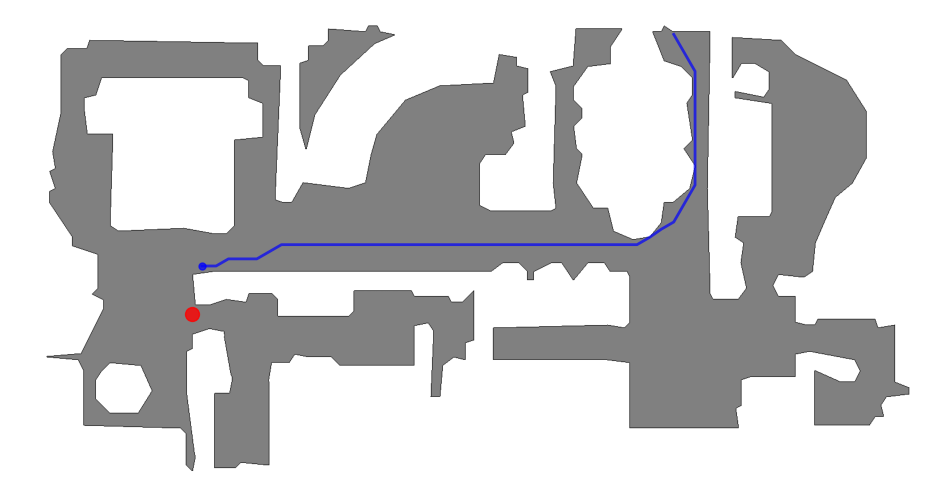

In [9]:
draw_path([data[1]['sound_pos']] , data[1]['path_point'])